## Expert Validation Survey Analysis

This notebook analyses the results of the expert survey used to evaluate the clinical plausibility of the synthetic dataset. The analysis contains the results of answers derived from three clinicians, who rated 10 synthetic patient records based on a plausibility scale  of 1 (clearly artificial) to 5 (identical to real patient scenarios). Clinicians also provided overall plausibility rating of the dataset and opinions on its structure.

Note: Survey data included in this notebook shows strictly the results of the survey, while details about participants were removed for privacy reasons. 

In [1]:
#Import tools used for analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
#Upload survey results
df = pd.read_excel("validation_survey.xlsx")
display (df)

#Select columns with only numerical values for analysis
numerical_df = df.select_dtypes(include='number')

#Drop NaN values
numerical_df = numerical_df.dropna(axis=1)
display(numerical_df)

,How would you rate the overall clinical plausibility of this record?,Is there anything specific in this record that seems clinically inconsistent?,"You answered ""Yes"" to the previous question, please explain why.",How would you rate the overall clinical plausibility of this record?2,Is there anything specific in this record that seems clinically inconsistent?2,"You answered ""Yes"" to the previous question, please explain why.2",How would you rate the overall clinical plausibility of this record?3,Is there anything specific in this record that seems clinically inconsistent?3,"You answered ""Yes"" to the previous question, please explain why.3",How would you rate the overall clinical plausibility of this record?4,...,Is there anything specific in this record that seems clinically inconsistent?9,"You answered ""Yes"" to the previous question, please explain why.9",How would you rate the overall clinical plausibility of this record?10,Is there anything specific in this record that seems clinically inconsistent?10,"You answered ""Yes"" to the previous question, please explain why.10","Overall, how would you rate the clinical realism of the patient records you reviewed during labelling?",Did the range of patient presentations feel consistent with what you would expect from the results of a real opioid toxicity risk assessment?,Were there any clinical factors relevant to opioid toxicity risk assessment that you felt were absent or insufficiently captured across the records?,Please describe which factors you felt were missing or insufficiently captured\n,Do you have any other observations about the overall quality of the dataset?
0,4,No,NaN,3,No,NaN,5,No,NaN,4,...,Yes,"It feels symptom heavy, could be realistic but...",4,No,NaN,3,3,Yes,"I would've liked to see symptom duration, whic...",NaN
1,4,No,NaN,3,No,NaN,4,No,NaN,5,...,No,NaN,4,No,NaN,4,4,Yes,I would have liked to see if the vital measure...,NaN
2,4,No,NaN,4,No,NaN,5,No,NaN,4,...,No,NaN,4,No,NaN,4,4,No,NaN,NaN


,How would you rate the overall clinical plausibility of this record?,How would you rate the overall clinical plausibility of this record?2,How would you rate the overall clinical plausibility of this record?3,How would you rate the overall clinical plausibility of this record?4,How would you rate the overall clinical plausibility of this record?5,How would you rate the overall clinical plausibility of this record?6,How would you rate the overall clinical plausibility of this record?7,How would you rate the overall clinical plausibility of this record?8,How would you rate the overall clinical plausibility of this record?9,How would you rate the overall clinical plausibility of this record?10,"Overall, how would you rate the clinical realism of the patient records you reviewed during labelling?",Did the range of patient presentations feel consistent with what you would expect from the results of a real opioid toxicity risk assessment?
0,4,3,5,4,3,4,3,4,3,4,3,3
1,4,3,4,5,4,4,3,3,3,4,4,4
2,4,4,5,4,4,4,3,4,3,4,4,4


#### Plausibility Analysis (per record)

This section includes an analysis of plausibility ratings per record to understand the scores provided by all three clinicians. Each record is analyzed by computing the mean, showing the average rating across clinicians, and the standard deviation showing variations across ratings. 

,scenario_1,scenario_2,scenario_3,scenario_4,scenario_5,scenario_6,scenario_7,scenario_8,scenario_9,scenario_10
0,4,3,5,4,3,4,3,4,3,4
1,4,3,4,5,4,4,3,3,3,4
2,4,4,5,4,4,4,3,4,3,4


scenario_1     4.00
scenario_2     3.33
scenario_3     4.67
scenario_4     4.33
scenario_5     3.67
scenario_6     4.00
scenario_7     3.00
scenario_8     3.67
scenario_9     3.00
scenario_10    4.00
dtype: float64
scenario_1     0.00
scenario_2     0.58
scenario_3     0.58
scenario_4     0.58
scenario_5     0.58
scenario_6     0.00
scenario_7     0.00
scenario_8     0.58
scenario_9     0.00
scenario_10    0.00
dtype: float64


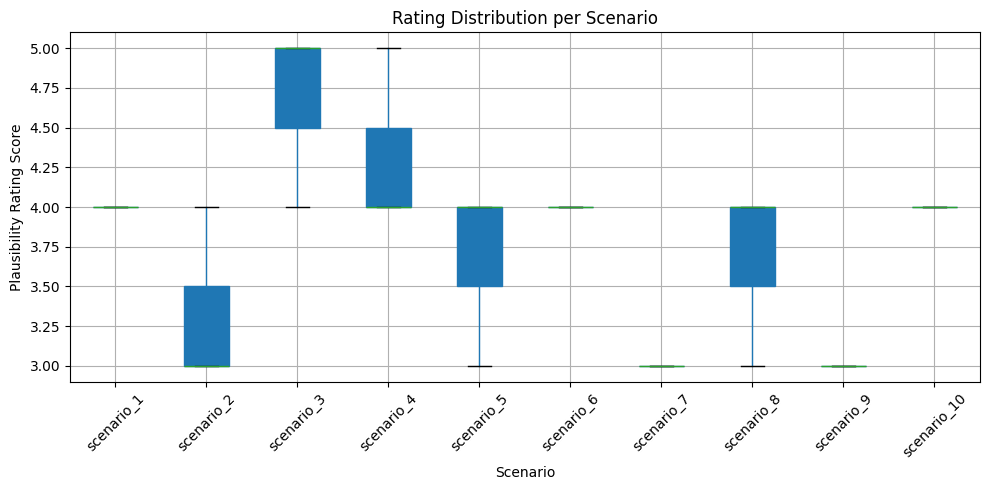

In [3]:
#Filter and select only the columns representing rating for individual patient scenario
patient_records = numerical_df.iloc[:, 0:10]

#Rename columns
patient_records.columns = [f"scenario_{i}" for i in range(1, 11)]
display(patient_records)

#Calculate mean and standard deviation for each scenario
mean = patient_records.mean(axis=0).round(2)
sd = patient_records.std(axis=0).round(2)

print(mean)
print(sd)

#Set boxplot to visualize distribution
ax = patient_records.boxplot(figsize=(10, 5), patch_artist=True)
plt.ylabel('Plausibility Rating Score')
plt.xlabel('Scenario')
plt.title('Rating Distribution per Scenario')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('rating_distribution.pdf', bbox_inches='tight')
plt.show()

The analysis reveals the mean plausibility ratings across the three clinicians range from 3.00 to 4.67, with no scenarios rated under 3. This indicates that all scenarios received a score of moderate realism or higher, with none considered artificial. 

Five records received perfect agreement across all three experts, showing a standard deviation of 0, while the rest showing a standard deviation of 0.58. This reflects disagreement of at most one point, reflecting strong consistency across expert rating. 

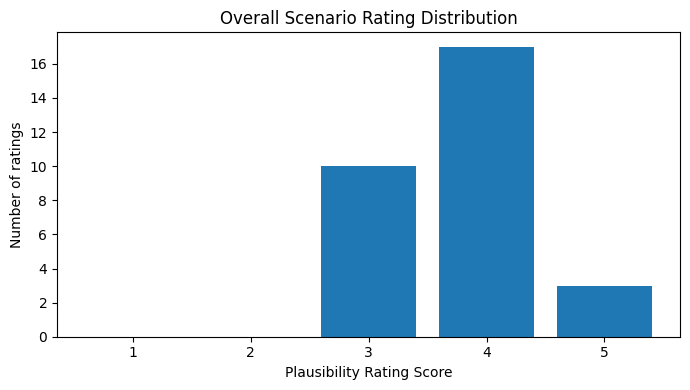

In [4]:
#Count all ratings across all scenarios from the three clinicians
ratings = patient_records.values.flatten().tolist()
counts = [ratings.count(v) for v in [1, 2, 3, 4, 5]]

#Set plot for overall rating distribution
plt.figure(figsize=(7, 4))
plt.bar([1, 2, 3, 4, 5], counts)
plt.xlabel('Plausibility Rating Score')
plt.ylabel('Number of ratings')
plt.title('Overall Scenario Rating Distribution')
plt.savefig('overall_rating.pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()

The visualization shows no records were rated below 3, indicating that clinicians perceived the generated patient scenarios as at least moderately realistic. The ratings were mostly around scores of 3 and 4, with few synthetic scenarios receiving a score of 5, meaning clinicians recognized it as a scenario identical to real patient records. 

#### Plausibility Analysis (dataset)

This section analyzes the survey results in terms of clinical plausibility and consistency of the overall dataset. Two survey questions were asked to assess how clinicians perceived the dataset as a whole:
- Q35 = Overall, how would you rate the clinical realism of the patient records you reviewed during labelling?
- Q36 = Did the range of patient presentations feel consistent with what you would expect from the results of a real opioid toxicity risk assessment? (On a scale 1-5, with 5 representing perfect consistency)

In [5]:
#Load scores for overall dataset plausibility
overall_scores = numerical_df.iloc[:, -2] 

#Compute mean, standard deviation and median
overall_mean = np.mean(overall_scores)
overall_sd = np.std(overall_scores)
overall_median = np.median(overall_scores)

print(f'Mean: {round(overall_mean, 2)}')
print(f'Standard deviation: {round(overall_sd, 2)}')
print(f'Median: {round(overall_median, 2)}')

Mean: 3.67
Standard deviation: 0.47
Median: 4.0


In [6]:
#Load scores for overall dataset consistency
overall_consistency = numerical_df.iloc[:, -1] 

#Compute mean, standard deviation and median
consistency_mean = np.mean(overall_consistency)
consistency_sd = np.std(overall_consistency)
consistency_median = np.median(overall_consistency)

print(f'Mean: {round(consistency_mean, 2)}')
print(f'Standard deviation: {round(consistency_sd, 2)}')
print(f'Median: {round(consistency_median, 2)}')

Mean: 3.67
Standard deviation: 0.47
Median: 4.0


Clinicians rated the overall medical realism and plausibility of the dataset at a mean of 3.67, suggesting their perceptions of the dataset range from moderate to high realism. The median, with a score of 4, indicates the clinicians believe the dataset leans towards realistic and plausible synthetic scenarios. The low standard deviation (0.47) shows moderate agreement between the clinicians across these ratings.

The same scores are reflected for the evaluation of the dataset's consistency, indicating that clinicians rated the synthetic records as representative of real opioid toxicity presentations across patients. 